<a href="https://colab.research.google.com/github/aydanali/ECON3916-Stats-and-ML/blob/main/Project1/StatsML_Project1_Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Racial Biases in Hiring: The Effect of Race on Hiring Practices
Aydan Ali

Statistics and Machine Learning: Project 1 Phase 2

03.10.2026


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

Dataset is from the [Bertrand & Mullainathan’s (2004) Resume Experiment](https://www.nber.org/papers/w9873). This data was collected and processed by Bertrand & Mullainathan. The dataset was obtained from OpenIntro, an independent non-profit who specialize in high-quality and accessible educational tools for teachers and students. The link for this dataset and its metadata is: https://www.openintro.org/data/index.php?data=resume.



In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

df_raw = pd.read_csv('gdrive/My Drive/callbacks_experiement_data.csv')

df_raw

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,job_ad_id,job_city,job_industry,job_type,job_fed_contractor,job_equal_opp_employer,job_ownership,job_req_any,job_req_communication,job_req_education,...,honors,worked_during_school,years_experience,computer_skills,special_skills,volunteer,military,employment_holes,has_email_address,resume_quality
0,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,0,6,1,0,0,0,1,0,low
1,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,1,6,1,0,1,1,0,1,high
2,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,1,6,1,0,0,0,0,0,low
3,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,0,6,1,1,1,0,1,1,high
4,385,Chicago,other_service,secretary,0.0,1,nonprofit,1,0,0,...,0,1,22,1,0,0,0,0,1,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4865,1344,Boston,finance_insurance_real_estate,secretary,0.0,0,private,1,0,0,...,0,0,1,1,1,0,0,1,0,low
4866,382,Boston,other_service,manager,NaN,0,unknown,0,0,0,...,0,1,6,1,0,0,0,0,0,low
4867,382,Boston,other_service,manager,NaN,0,unknown,0,0,0,...,0,1,8,1,0,1,0,0,1,high
4868,382,Boston,other_service,manager,NaN,0,unknown,0,0,0,...,0,1,2,1,0,1,1,0,1,high


In [ ]:
df_raw.describe()

,job_ad_id,job_fed_contractor,job_equal_opp_employer,job_req_any,job_req_communication,job_req_education,job_req_computer,job_req_organization,received_callback,years_college,college_degree,honors,worked_during_school,years_experience,computer_skills,special_skills,volunteer,military,employment_holes,has_email_address
count,4870.000000,3102.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000
mean,651.777823,0.114765,0.291170,0.787269,0.124846,0.106776,0.437166,0.072690,0.080493,3.618480,0.719507,0.052772,0.559548,7.842916,0.820534,0.328747,0.411499,0.097125,0.448049,0.479261
std,388.690698,0.318789,0.454349,0.409281,0.330578,0.308860,0.496087,0.259654,0.272083,0.714997,0.449286,0.223601,0.496492,5.044612,0.383782,0.469806,0.492156,0.296159,0.497345,0.499621
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,306.250000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,647.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,6.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,979.750000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,9.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,1344.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,44.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_ad_id               4870 non-null   int64  
 1   job_city                4870 non-null   object 
 2   job_industry            4870 non-null   object 
 3   job_type                4870 non-null   object 
 4   job_fed_contractor      3102 non-null   float64
 5   job_equal_opp_employer  4870 non-null   int64  
 6   job_ownership           4870 non-null   object 
 7   job_req_any             4870 non-null   int64  
 8   job_req_communication   4870 non-null   int64  
 9   job_req_education       4870 non-null   int64  
 10  job_req_min_experience  2124 non-null   object 
 11  job_req_computer        4870 non-null   int64  
 12  job_req_organization    4870 non-null   int64  
 13  job_req_school          4870 non-null   object 
 14  received_callback       4870 non-null   

<Axes: >

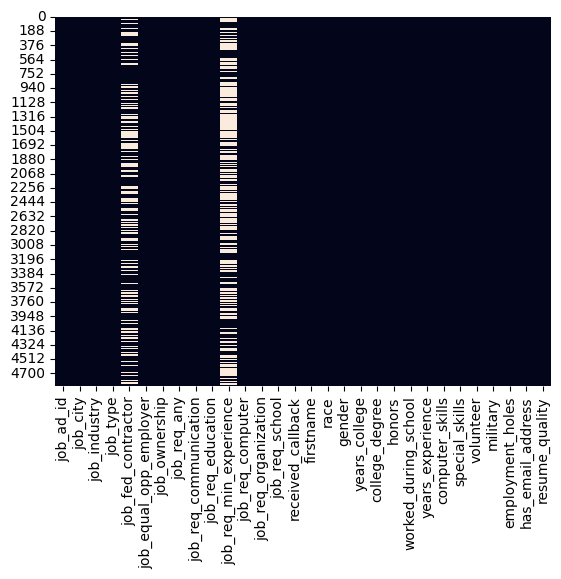

In [ ]:
sns.heatmap(df_raw.isnull(), cbar=False)

In [ ]:
print('Unique Values in job_fed_contractor: ', df_raw['job_fed_contractor'].unique())
print('Unique Values in job_req_min_experience: ', df_raw['job_req_min_experience'].unique())

Unique Values in job_fed_contractor:  [nan  0.  1.]
Unique Values in job_req_min_experience:  ['5' 'some' nan '3' '2' '1' '8' '7' '0.5' '10' '0' '4' '6']


Looking at the dataframe from the descriptors, info, and heatmap, we can see that it is almost entirely complete with some missing data in two columns: job_fed_contractor and job_req_min_experience. The prevalance of the missing data and and completeness of all the other field led me to believe that the data was not really incomplete (Missing Completely at Random/MCAR) but structurally missing. Taking a closer look at the raw data .csv file and the meta data, I concluded that the missing data represents a "0" or "none" value.

This would make sense for job_req_min_experience, which represents the amount of experience required for the job. I would assume that the NaN values represent no experience needed, espically given its prevalance in the data. Although, the value of "0" is used too, so it is hard to confiently make that assumption.

In the case of the column job_fed_contractor, which is the indicator for if the employer is a federal contractor, I have some issues. In the raw data for the file, there are values for "0" (no) or "1" (yes) already inputted. The values that canme back as NaN are written as "NA" in the file. I cannot confiendtly claim what the "NA" values represent since a company can only be or not be a federal contractor. It could be not applicable to the specific job listing, but there would be no way determining that since the job listings are anonymous.

In both these cases, I will, for now, assume that the NaN is a "0" value, and the issues were just differences with the collection of the data.

In [ ]:
df = df_raw.fillna(0)

df

,job_ad_id,job_city,job_industry,job_type,job_fed_contractor,job_equal_opp_employer,job_ownership,job_req_any,job_req_communication,job_req_education,...,honors,worked_during_school,years_experience,computer_skills,special_skills,volunteer,military,employment_holes,has_email_address,resume_quality
0,384,Chicago,manufacturing,supervisor,0.0,1,unknown,1,0,0,...,0,0,6,1,0,0,0,1,0,low
1,384,Chicago,manufacturing,supervisor,0.0,1,unknown,1,0,0,...,0,1,6,1,0,1,1,0,1,high
2,384,Chicago,manufacturing,supervisor,0.0,1,unknown,1,0,0,...,0,1,6,1,0,0,0,0,0,low
3,384,Chicago,manufacturing,supervisor,0.0,1,unknown,1,0,0,...,0,0,6,1,1,1,0,1,1,high
4,385,Chicago,other_service,secretary,0.0,1,nonprofit,1,0,0,...,0,1,22,1,0,0,0,0,1,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4865,1344,Boston,finance_insurance_real_estate,secretary,0.0,0,private,1,0,0,...,0,0,1,1,1,0,0,1,0,low
4866,382,Boston,other_service,manager,0.0,0,unknown,0,0,0,...,0,1,6,1,0,0,0,0,0,low
4867,382,Boston,other_service,manager,0.0,0,unknown,0,0,0,...,0,1,8,1,0,1,0,0,1,high
4868,382,Boston,other_service,manager,0.0,0,unknown,0,0,0,...,0,1,2,1,0,1,1,0,1,high


<Axes: >

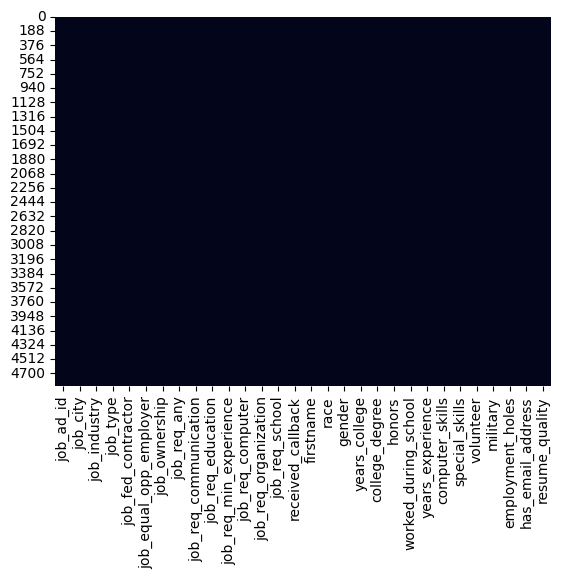

In [ ]:
sns.heatmap(df.isnull(), cbar=False)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


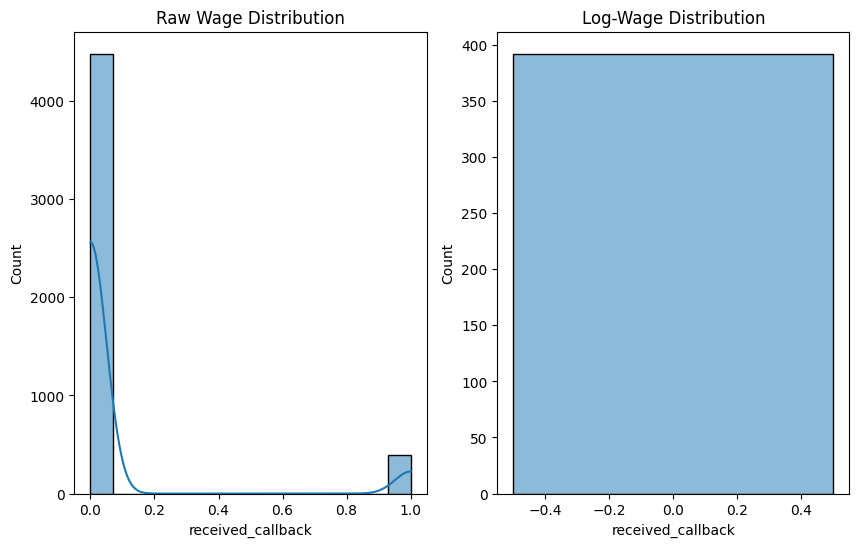

In [ ]:
 # Requirement 1: The Univariate Distribution (The "Money Illusion" Check)

# Visualizing the log-transformation
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['received_callback'], kde=True)
plt.title("Raw Callback Distribution")

plt.subplot(1, 2, 2)
sns.histplot(np.log(df['received_callback']), kde=True)
plt.title("Log-Callback Distribution")

plt.show()

The data is discrete and binary. The outcome, whether a candidate recieved a callback, has only two options: yes (1) or no (0). Showing the distribution of the data does not provide much substance other than the frequency of the outcome. The log-adjusted data shows no value. The log of 0 is undefined and the log of 1 is 0, so all information is distored.

<Axes: title={'center': 'The Bivariate Relationship'}, xlabel='race', ylabel='received_callback'>

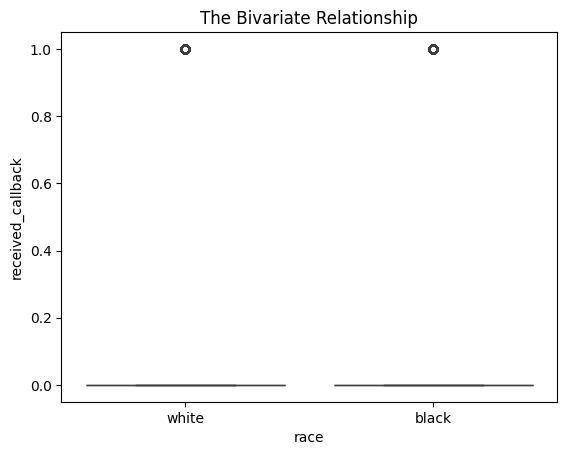

In [ ]:
 # Requirement 2: The Bivariate Relationship (The "Eyeball Test")

plt.title('The Bivariate Relationship')
sns.boxplot(df, x='race', y='received_callback')

We run into a similar issue with this requirement. A boxplot of binary data shows the median of data that is either 0 or 1. Looking at the box plot, we see the median is 0 for both white and black applicants, which would show us that the majority of applicants of either race did not recieve a call back. A better show of the relationship between the independent and dependant variables would be a chart showing the callback rate for each rate. Given that the data gave each race has the same qualification, a difference in callback rate would show discrimination.

Text(0, 0.5, 'Callback Rate')

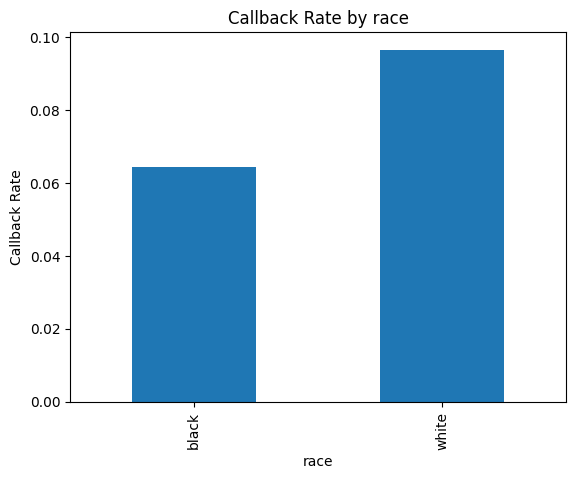

In [ ]:
callback_rates = df.groupby('race')['received_callback'].mean()
callback_rates.plot(kind='bar')

plt.title('Callback Rate by race')
plt.ylabel('Callback Rate')

In [ ]:
 # Requirement 3: Outlier Detection (Robust Statistics)

This data does not have an outliers or extreme values. Given that most of the data is fictitious and created by the authors of the original experience, it is by design random and non-extreme. There is also no outliers when looking at the independent and dependent variable as those are both binary.

If you would like to know more about the creation of the data, you can find the methods in [section 3.1 and 3.2 of Bertrand & Mullainathan’s paper on the original experiment](https://www.nber.org/system/files/working_papers/w9873/w9873.pdf) (pgs. 6-8).